In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold

In [ ]:
waka_dragon_df = pd.read_csv("data/waka_dragon_merged.csv")
mX_df = waka_dragon_df.loc[:, 'MW':]

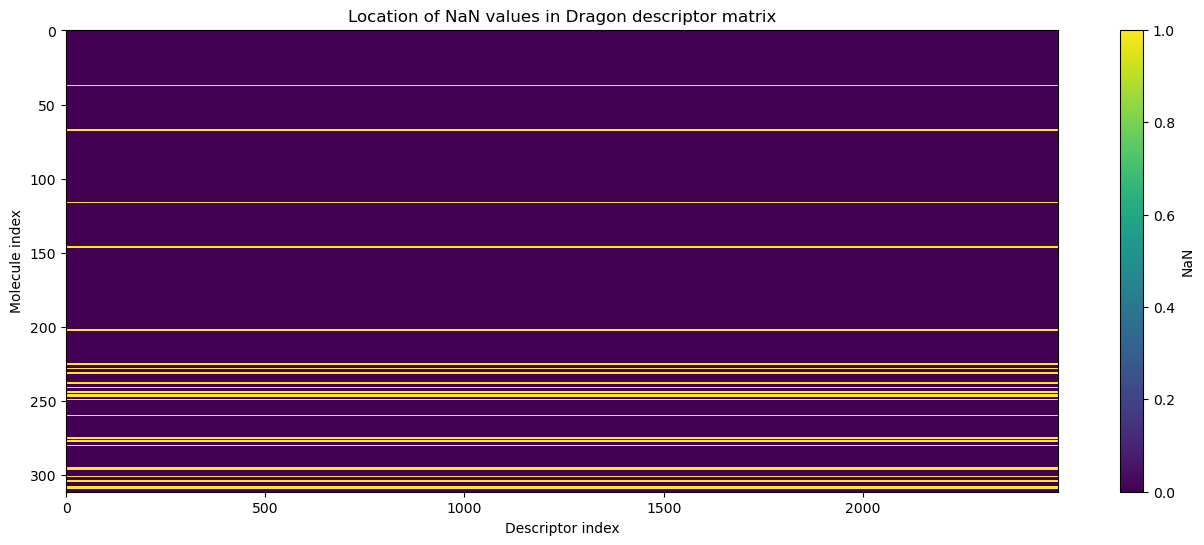

In [24]:
plt.figure(figsize=(16, 6))

plt.imshow(
    mX_df.isna(),
    aspect='auto',
    interpolation='none'
)

plt.xlabel('Descriptor index')
plt.ylabel('Molecule index')
plt.title('Location of NaN values in Dragon descriptor matrix')

plt.colorbar(label='NaN')
plt.show()

In [25]:
valid_mask = ~mX_df.isna().all(axis=1)
valid_mask

0       True
1       True
2       True
3       True
4       True
       ...  
307     True
308    False
309    False
310     True
311     True
Length: 312, dtype: bool

In [26]:
mX_df = waka_dragon_df.loc[valid_mask, 'MW':]

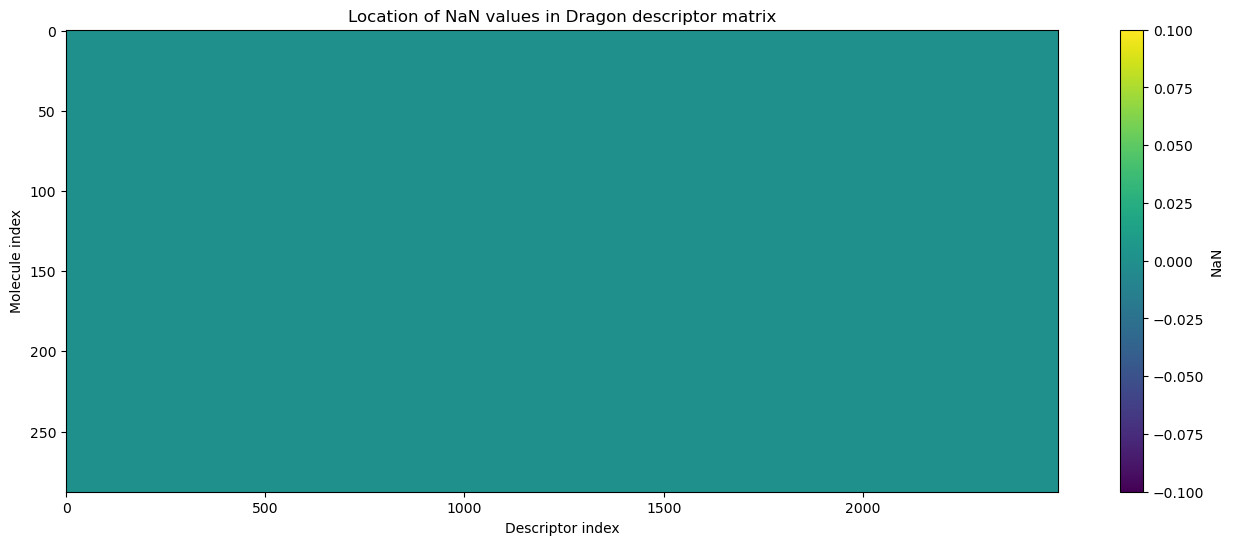

In [27]:
plt.figure(figsize=(16, 6))

plt.imshow(
    mX_df.isna(),
    aspect='auto',
    interpolation='none'
)

plt.xlabel('Descriptor index')
plt.ylabel('Molecule index')
plt.title('Location of NaN values in Dragon descriptor matrix')

plt.colorbar(label='NaN')
plt.show()

In [28]:
waka_dragon_df = waka_dragon_df.loc[valid_mask,:]
waka_dragon_df

,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,AMW,Sv,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,6.294,7.537,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,7.581,9.295,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,6.759,9.822,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,8.597,12.010,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,6.444,13.876,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,15461361,67883-79-8,cis-3-hexenyl tiglate,44.85,0.01,0.63,1,182.29,5.880,17.171,...,115.496,208.52,0.847,-3.74,-3.95,-4.00,0.0,50.0,0.036,0.0
306,16063567,141773-73-1,helvetolide,7.05,-0.75,0.22,0,284.49,5.471,27.573,...,175.508,314.03,0.838,-4.20,-4.46,-4.54,1.0,98.0,0.017,0.0
307,16070752,117933-89-8,karanal,48.88,-1.32,0.50,1,266.47,5.438,26.332,...,164.119,292.88,0.873,-4.57,-4.87,-4.97,2.0,98.0,0.016,0.0
310,44153588,113889-23-9,tricyclodecenyl butyrate,24.15,-0.51,0.11,0,220.34,6.121,20.698,...,125.021,225.98,0.930,-4.19,-4.44,-4.52,6.0,88.0,0.021,0.0


In [29]:
vY_Imax = waka_dragon_df['Imax']

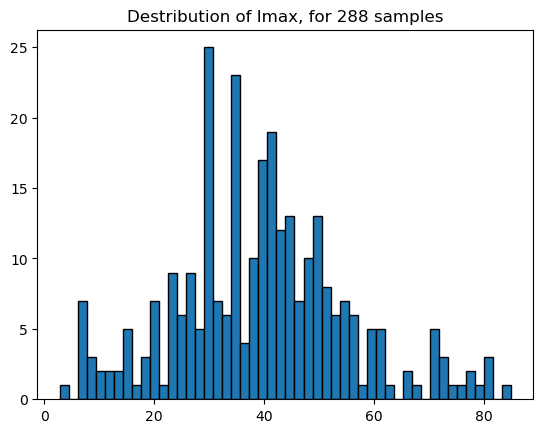

In [32]:
import matplotlib.pyplot as plt
plt.hist(vY_Imax, bins = 50, edgecolor='k')
plt.title(f"Destribution of Imax, for {len(vY_Imax)} samples")
plt.show()

In [33]:
#first we remove features with zero variance
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0) #object 

mX1 = vt.fit_transform(mX_df) #returns NDArray

# mX1_df becomes the updated feature matrix
mX1_df = pd.DataFrame(
    mX1,
    columns=mX_df.columns[vt.get_support()],
    index=mX_df.index
)

print(mX1_df.shape)

(288, 2484)


In [34]:
# correlations matrix
corr_matrix = mX1_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95) # May be the correlation threshold should be lower
]

print(f"Descriptors to remove: {len(to_drop)}")

Descriptors to remove: 1650


In [35]:
# Dropping of high correlated descriptors
mX2_df = mX1_df.drop(columns=to_drop)
print(mX2_df.shape)

(288, 834)


In [12]:
n_cols_with_nan = mX2_df.isna().any(axis=0).sum()

print(f"Columns containing NaN: {n_cols_with_nan}")
print(f"Total columns: {mX2_df.shape[1]}")

Columns containing NaN: 834
Total columns: 834


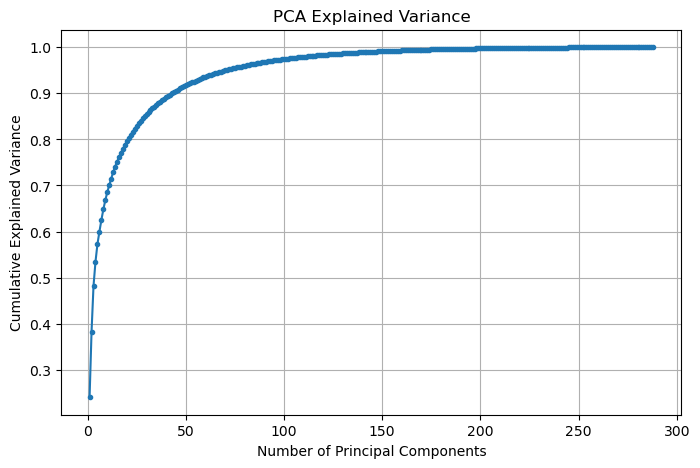

In [37]:
# This is the place i want to do PCA to reduce the noice
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
mX2_scaled = scaler.fit_transform(mX2_df)

# PCA
pca = PCA()
pca.fit(mX2_scaled)

# Cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker='o',
    markersize=3
)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

In [65]:
n_pc_98 = np.argmax(cum_var >= 0.98) + 1
print(f"98% variance requires {n_pc_98} principal components")

98% variance requires 112 principal components


In [66]:
pca98 = PCA(n_components=n_pc_98)
mX_pca98 = pca98.fit_transform(mX2_scaled)

# Convert back to DataFrame
pc_names = [f'PC{i+1}' for i in range(mX_pca98.shape[1])]

mX_pca98_df = pd.DataFrame(
    mX_pca98,
    columns=pc_names,
    index=mX2_df.index
)

print(mX_pca98_df.shape)
mX_pca98_df.head()

(288, 112)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC103,PC104,PC105,PC106,PC107,PC108,PC109,PC110,PC111,PC112
0,-34.930641,-2.743480,8.778009,15.604069,-7.471722,6.393372,-6.461598,-21.575710,7.434656,-1.271414,...,0.625019,-0.869914,-0.343545,-0.334497,-0.258069,0.049539,0.044264,0.429287,-0.906328,-0.157160
1,-28.615653,5.375469,1.111428,-10.184173,-4.113885,-0.788431,-0.755220,-3.139950,-0.077142,6.605779,...,0.076492,-0.917019,-0.131274,-0.465203,-0.364652,1.005389,-0.238626,-0.324019,0.251599,-0.239339
2,-29.587111,7.451967,3.905728,-7.496176,-0.660173,5.853612,-1.207577,-5.582419,6.534548,1.891510,...,-0.064402,-0.312045,0.647303,-0.830712,-0.826208,-0.325575,0.271723,-0.560415,-0.400643,0.806614
3,-17.225450,18.274201,-2.002230,-8.620034,-6.235685,-2.209887,3.992845,1.852887,-3.331904,3.569933,...,0.254431,0.293880,0.381755,0.185161,0.512913,-0.191702,0.536073,0.852053,-0.435931,0.811628
4,-10.441494,7.294321,0.547114,-6.355677,4.155585,3.810130,4.954488,-1.490658,-2.830488,3.492211,...,0.125195,0.757454,1.302743,-0.051178,-0.465949,0.458367,1.261635,-0.212846,0.128682,-0.071795


In [67]:
vY_Imax.shape

(288,)

In [ ]:
xgb_reg = XGBRegressor(
    objective="reg:absoluteerror",
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_reg.fit(mX_pca98_df, vY_Imax)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [69]:
pca_names = [f'PC{i+1}' for i in range(mX_pca98.shape[1])]
importance = pd.Series(
    xgb_reg.feature_importances_,
    index= pca_names
).sort_values(ascending=False)

importance.head(60)

PC1      0.011342
PC61     0.010658
PC60     0.010650
PC70     0.010562
PC52     0.010544
PC59     0.010437
PC112    0.010390
PC37     0.010384
PC95     0.010375
PC14     0.010359
PC83     0.010357
PC73     0.010221
PC104    0.010166
PC90     0.010132
PC56     0.010051
PC47     0.009955
PC9      0.009902
PC41     0.009830
PC87     0.009811
PC44     0.009800
PC62     0.009798
PC93     0.009796
PC35     0.009781
PC49     0.009764
PC20     0.009742
PC4      0.009729
PC46     0.009683
PC38     0.009674
PC2      0.009611
PC28     0.009605
PC53     0.009605
PC101    0.009600
PC33     0.009574
PC64     0.009548
PC23     0.009465
PC71     0.009437
PC26     0.009412
PC74     0.009408
PC91     0.009387
PC77     0.009369
PC102    0.009338
PC10     0.009332
PC15     0.009328
PC110    0.009322
PC68     0.009295
PC80     0.009292
PC24     0.009268
PC54     0.009248
PC66     0.009178
PC100    0.009167
PC13     0.009155
PC29     0.009155
PC99     0.009101
PC42     0.009091
PC79     0.009081
PC51     0

In [70]:
importance

PC1      0.011342
PC61     0.010658
PC60     0.010650
PC70     0.010562
PC52     0.010544
           ...   
PC107    0.007265
PC17     0.007157
PC36     0.007054
PC5      0.006200
PC7      0.006120
Length: 112, dtype: float32

In [71]:
top60_reg_features = importance.index[:60]
top60_reg_features

Index(['PC1', 'PC61', 'PC60', 'PC70', 'PC52', 'PC59', 'PC112', 'PC37', 'PC95',
       'PC14', 'PC83', 'PC73', 'PC104', 'PC90', 'PC56', 'PC47', 'PC9', 'PC41',
       'PC87', 'PC44', 'PC62', 'PC93', 'PC35', 'PC49', 'PC20', 'PC4', 'PC46',
       'PC38', 'PC2', 'PC28', 'PC53', 'PC101', 'PC33', 'PC64', 'PC23', 'PC71',
       'PC26', 'PC74', 'PC91', 'PC77', 'PC102', 'PC10', 'PC15', 'PC110',
       'PC68', 'PC80', 'PC24', 'PC54', 'PC66', 'PC100', 'PC13', 'PC29', 'PC99',
       'PC42', 'PC79', 'PC51', 'PC65', 'PC72', 'PC55', 'PC85'],
      dtype='str')

In [72]:
X_top60 = mX_pca98_df[top60_reg_features].copy()

print(X_top60.shape)

(288, 60)


In [73]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_reg,
    X_top60,
    vY_Imax,
    scoring="neg_mean_absolute_error",
    cv=cv
)

print("CV MAE:", -scores.mean())
print("STD:", scores.std())

CV MAE: 8.468888697601706
STD: 0.7732496151579101


In [75]:
importance = pd.Series(
    xgb_reg.feature_importances_,
    index=mX_pca98_df.columns
).sort_values(ascending=False)

In [76]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(10, 115, 5):

    top_features = importance.index[:n_features]

    X_subset = mX_pca98_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY_Imax,
        cv=cv
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,10,9.743107,0.330169
1,15,9.817066,0.325696
2,20,9.188396,0.425491
3,25,9.104809,0.439562
4,30,8.470018,0.502342
5,35,8.354485,0.507978
6,40,8.484708,0.497736
7,45,8.478647,0.491416
8,50,8.500166,0.486854
9,55,8.417998,0.496623


In [77]:
results_df.sort_values('MAE')

,n_features,MAE,R2
5,35,8.354485,0.507978
9,55,8.417998,0.496623
4,30,8.470018,0.502342
10,60,8.473489,0.490936
7,45,8.478647,0.491416
6,40,8.484708,0.497736
8,50,8.500166,0.486854
11,65,8.543413,0.474807
12,70,8.595298,0.481553
15,85,8.600544,0.480624


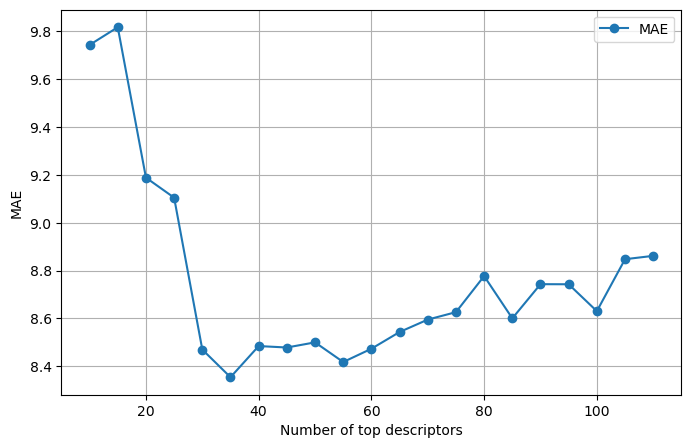

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['MAE'],
    marker='o',
    label='MAE'
)

plt.xlabel('Number of top PC descriptors')
plt.ylabel('MAE')
plt.grid(True)
plt.legend()

plt.show()

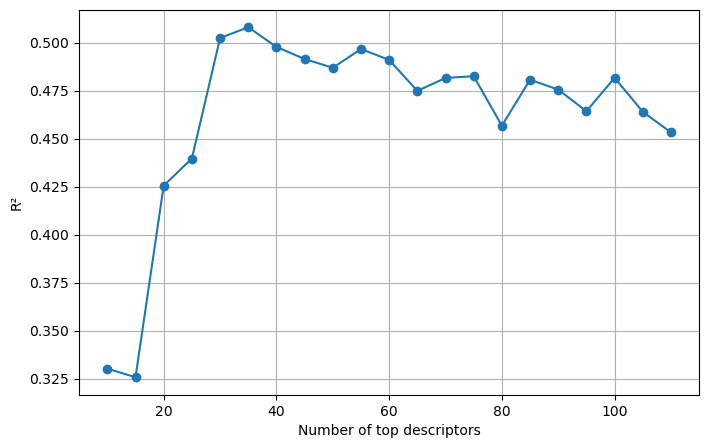

In [79]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['R2'],
    marker='o'
)

plt.xlabel('Number of top descriptors')
plt.ylabel('R²')
plt.grid(True)

plt.show()

In [81]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(30, 61, 1):

    top_features = importance.index[:n_features]

    X_subset = mX_pca98_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY_Imax,
        cv=cv
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,30,8.470018,0.502342
1,31,8.330520,0.514960
2,32,8.283366,0.528817
3,33,8.371718,0.512890
4,34,8.357477,0.500537
5,35,8.354485,0.507978
6,36,8.452898,0.497093
7,37,8.354368,0.509155
8,38,8.285573,0.514871
9,39,8.379368,0.512692


In [82]:
results_df.sort_values('MAE')

,n_features,MAE,R2
14,44,8.258716,0.504548
2,32,8.283366,0.528817
8,38,8.285573,0.514871
11,41,8.315038,0.510297
1,31,8.330520,0.514960
7,37,8.354368,0.509155
5,35,8.354485,0.507978
24,54,8.354786,0.513135
4,34,8.357477,0.500537
12,42,8.370880,0.499666


In [83]:
# Fix the selected feature set
top44 = importance.index[:44]
X44 = mX_pca98_df[top44].copy()

print(X44.shape)
print(top44)

(288, 44)
Index(['PC1', 'PC61', 'PC60', 'PC70', 'PC52', 'PC59', 'PC112', 'PC37', 'PC95',
       'PC14', 'PC83', 'PC73', 'PC104', 'PC90', 'PC56', 'PC47', 'PC9', 'PC41',
       'PC87', 'PC44', 'PC62', 'PC93', 'PC35', 'PC49', 'PC20', 'PC4', 'PC46',
       'PC38', 'PC2', 'PC28', 'PC53', 'PC101', 'PC33', 'PC64', 'PC23', 'PC71',
       'PC26', 'PC74', 'PC91', 'PC77', 'PC102', 'PC10', 'PC15', 'PC110'],
      dtype='str')


In [84]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_base = XGBRegressor(
    objective="reg:absoluteerror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X44, vY_Imax)

print("Best CV MAE:", -grid.best_score_)
print("Best params:")
print(grid.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best CV MAE: 7.981731544021542
Best params:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 800, 'subsample': 0.7}


In [91]:
best_xgb = XGBRegressor(
    objective='reg:absoluteerror',
    colsample_bytree=0.7,
    learning_rate=0.03,
    max_depth=2,
    n_estimators=800,
    subsample=0.7,
    random_state=42
)

In [92]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(
    best_xgb,
    X44,
    vY_Imax,
    cv=cv
)

In [93]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(vY_Imax, y_pred)
r2 = r2_score(vY_Imax, y_pred)

print(f"MAE = {mae:.3f}")
print(f"R²  = {r2:.3f}")

MAE = 8.150
R²  = 0.522


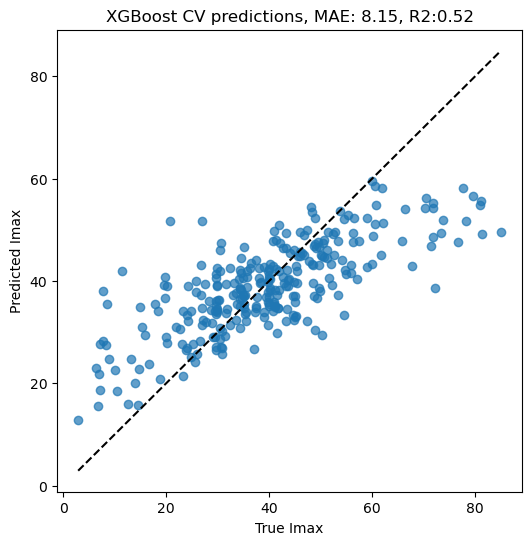

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(vY_Imax, y_pred, alpha=0.7)

plt.plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

plt.xlabel("True Imax")
plt.ylabel("Predicted Imax")
plt.title(f"XGBoost CV predictions, MAE: {mae:.2f}, R2:{r2:.2f}")

plt.show()

In [96]:
log_vp_df = pd.read_csv('data/waka_with_imputed_vp.csv')
log_vp_df = log_vp_df.loc[valid_mask,:]
merged_waka_vp = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    log_vp_df[['CID', 'log_vp']],
    on='CID',
    how='left'
)
X45 = X44.copy()
X45['log_vp'] = merged_waka_vp['log_vp']
X45

,PC1,PC61,PC60,PC70,PC52,PC59,PC112,PC37,PC95,PC14,...,PC71,PC26,PC74,PC91,PC77,PC102,PC10,PC15,PC110,log_vp
0,-34.930641,0.044568,-0.738956,-0.320702,-1.296016,-1.045850,-0.157160,3.926933,0.253430,-4.293458,...,-1.327951,2.066903,1.499144,0.626148,1.277114,1.333287,-1.271414,-2.243919,0.429287,-0.163905
1,-28.615653,-1.168378,0.465936,0.649566,1.343644,0.755183,-0.239339,2.210117,0.991322,3.909632,...,0.762508,-4.312020,-1.428728,1.003640,-0.511653,0.388678,6.605779,7.291847,-0.324019,-0.001051
2,-29.587111,1.815600,1.382160,0.383933,-1.474038,1.185951,0.806614,0.831130,1.600261,5.285284,...,-0.100360,0.406990,-1.362552,0.246841,-0.707857,0.076280,1.891510,2.088185,-0.560415,-1.004329
3,-17.225450,0.371895,0.272905,0.114159,0.905918,0.860427,0.811628,-1.153043,-2.567784,-1.717896,...,0.367519,0.434189,-0.023241,0.005276,1.104829,0.414916,3.569933,7.049398,0.852053,-3.008774
4,-10.441494,-1.238561,-0.164003,-1.335071,1.614049,0.847573,-0.071795,0.591025,0.259982,-2.810947,...,-0.956549,0.054364,0.726030,0.176975,-1.462614,-0.017912,3.492211,-0.164762,-0.212846,-1.254028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,4.181523,0.683524,-0.917122,0.598240,0.582701,-0.038588,-0.226018,-0.832892,0.098148,0.890673,...,0.741726,1.070552,-0.223672,0.744072,-0.689459,0.707963,7.688645,-1.990573,0.253727,NaN
306,41.884203,1.418733,0.343633,-1.115074,-2.038320,1.802296,-1.118644,-4.920089,0.859605,-2.392969,...,-1.271825,-0.537812,-1.568200,-0.867973,1.593920,0.763113,0.576730,-8.456862,-0.954392,NaN
307,34.721067,0.525662,1.420189,-1.956004,4.966634,-1.810568,0.100888,0.507318,0.396239,9.951696,...,0.239444,-1.322089,2.353913,-0.254433,0.935489,-0.528878,2.869249,-6.626790,0.300520,NaN
310,17.178834,-0.373993,-0.631285,0.714555,1.502286,-0.427159,-0.669828,-0.632212,0.537528,1.215650,...,-0.716412,-3.539543,-0.000877,0.465045,-0.420963,0.369108,-3.905649,0.771435,0.422725,NaN


In [136]:
y_pred_46 = cross_val_predict(
    best_xgb,
    X45,
    vY_Imax,
    cv=cv
)

In [137]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_45 = mean_absolute_error(vY_Imax, y_pred_46)
r2_45 = r2_score(vY_Imax, y_pred_46)

print(f"MAE = {mae_45:.3f}")
print(f"R²  = {r2_45:.3f}")

MAE = 8.131
R²  = 0.525


In [138]:
# now we try to add boiling point
bp_df = pd.read_csv('data/waka_with_imputed_bp.csv')
bp_df = bp_df.loc[valid_mask, :]
merged_waka_bp = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    bp_df[['CID', 'bp_value']],
    on='CID',
    how='left'
)
X46 = X45.copy()
X46['bp'] = merged_waka_bp['bp_value']
X46

,PC1,PC61,PC60,PC70,PC52,PC59,PC112,PC37,PC95,PC14,...,PC26,PC74,PC91,PC77,PC102,PC10,PC15,PC110,log_vp,bp
0,-34.930641,0.044568,-0.738956,-0.320702,-1.296016,-1.045850,-0.157160,3.926933,0.253430,-4.293458,...,2.066903,1.499144,0.626148,1.277114,1.333287,-1.271414,-2.243919,0.429287,-0.163905,147.500000
1,-28.615653,-1.168378,0.465936,0.649566,1.343644,0.755183,-0.239339,2.210117,0.991322,3.909632,...,-4.312020,-1.428728,1.003640,-0.511653,0.388678,6.605779,7.291847,-0.324019,-0.001051,178.889000
2,-29.587111,1.815600,1.382160,0.383933,-1.474038,1.185951,0.806614,0.831130,1.600261,5.285284,...,0.406990,-1.362552,0.246841,-0.707857,0.076280,1.891510,2.088185,-0.560415,-1.004329,205.500000
3,-17.225450,0.371895,0.272905,0.114159,0.905918,0.860427,0.811628,-1.153043,-2.567784,-1.717896,...,0.434189,-0.023241,0.005276,1.104829,0.414916,3.569933,7.049398,0.852053,-3.008774,299.000000
4,-10.441494,-1.238561,-0.164003,-1.335071,1.614049,0.847573,-0.071795,0.591025,0.259982,-2.810947,...,0.054364,0.726030,0.176975,-1.462614,-0.017912,3.492211,-0.164762,-0.212846,-1.254028,153.796459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,4.181523,0.683524,-0.917122,0.598240,0.582701,-0.038588,-0.226018,-0.832892,0.098148,0.890673,...,1.070552,-0.223672,0.744072,-0.689459,0.707963,7.688645,-1.990573,0.253727,NaN,NaN
306,41.884203,1.418733,0.343633,-1.115074,-2.038320,1.802296,-1.118644,-4.920089,0.859605,-2.392969,...,-0.537812,-1.568200,-0.867973,1.593920,0.763113,0.576730,-8.456862,-0.954392,NaN,NaN
307,34.721067,0.525662,1.420189,-1.956004,4.966634,-1.810568,0.100888,0.507318,0.396239,9.951696,...,-1.322089,2.353913,-0.254433,0.935489,-0.528878,2.869249,-6.626790,0.300520,NaN,NaN
310,17.178834,-0.373993,-0.631285,0.714555,1.502286,-0.427159,-0.669828,-0.632212,0.537528,1.215650,...,-3.539543,-0.000877,0.465045,-0.420963,0.369108,-3.905649,0.771435,0.422725,NaN,NaN


In [139]:
y_pred_46 = cross_val_predict(
    best_xgb,
    X46,
    vY_Imax,
    cv=cv
)

In [140]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_46 = mean_absolute_error(vY_Imax, y_pred_46)
r2_46 = r2_score(vY_Imax, y_pred_46)

print(f"MAE = {mae_46:.3f}")
print(f"R²  = {r2_46:.3f}")

MAE = 8.202
R²  = 0.522


In [141]:
print(
    (waka_dragon_df['CID'].values ==
     merged_waka_bp['CID'].values).all()
)

True


In [104]:
merged_waka_bp['bp_value'].corr(
    merged_waka_vp['log_vp']
)

np.float64(-0.7466852239427975)

In [142]:
importance_vp = pd.Series(
    best_xgb.fit(X46, vY_Imax).feature_importances_,
    index=X46.columns
).sort_values(ascending=False)

print(importance_vp.head(20))

PC1      0.033161
PC2      0.027090
PC4      0.025790
PC41     0.023842
PC15     0.023731
PC9      0.023684
PC49     0.023370
PC10     0.023338
PC28     0.023242
PC112    0.023180
PC37     0.023051
PC104    0.022657
PC70     0.022510
PC26     0.022361
PC14     0.022335
PC33     0.022066
PC52     0.022063
PC35     0.021687
PC90     0.021484
PC62     0.021310
dtype: float32


In [143]:
X46['log_vp']

0     -0.163905
1     -0.001051
2     -1.004329
3     -3.008774
4     -1.254028
         ...   
305         NaN
306         NaN
307         NaN
310         NaN
311         NaN
Name: log_vp, Length: 288, dtype: float64

In [144]:
y_pred_log_vp = cross_val_predict(
    best_xgb,
    X46[['log_vp']],
    vY_Imax,
    cv=cv
)

In [145]:
mae_log_vp = mean_absolute_error(vY_Imax, y_pred_log_vp)
r2_log_vp = r2_score(vY_Imax, y_pred_log_vp)

print(f"MAE = {mae_log_vp:.3f}")
print(f"R²  = {r2_log_vp:.3f}")

MAE = 12.565
R²  = -0.058


In [146]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    merged_waka_vp['log_vp'],
    vY_Imax
)

spearman_r, spearman_p = spearmanr(
    merged_waka_vp['log_vp'],
    vY_Imax
)

print(f"Pearson r  = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}")

Pearson r  = 0.690
Spearman r = 0.678


In [147]:
from catboost import CatBoostRegressor

In [148]:
cat_model = CatBoostRegressor(
    loss_function='MAE',
    iterations=1000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

In [149]:
y_pred_cat = cross_val_predict(
    cat_model,
    X46,
    vY_Imax,
    cv=cv
)

mae_cat = mean_absolute_error(vY_Imax, y_pred_cat)
r2_cat = r2_score(vY_Imax, y_pred_cat)

print(f"CatBoost MAE = {mae_cat:.3f}")
print(f"CatBoost R²  = {r2_cat:.3f}")

CatBoost MAE = 8.208
CatBoost R²  = 0.515


In [150]:
rd_kit_df = pd.read_csv('data/waka_rdkit_expert_features.csv')
rd_kit_df

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
308,16204527,isocyclocitral,304.474,4.8474,34.14,0.0,2.0,2.0,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
309,19871663,terpirosa,144.258,2.4395,20.23,1.0,1.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
310,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [151]:
rd_kit_df = rd_kit_df.loc[valid_mask, :]
rd_kit_df

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,15461361,cis-3-hexenyl tiglate,182.263,2.8521,26.30,0.0,2.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
306,16063567,helvetolide,284.440,4.3397,35.53,0.0,3.0,6.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
307,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
310,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [152]:

merged_waka_rd_kit = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    rd_kit_df.drop(columns='Name'),
    on='CID',
    how='left'
)
merged_waka_rd_kit

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,15461361,cis-3-hexenyl tiglate,182.263,2.8521,26.30,0.0,2.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
284,16063567,helvetolide,284.440,4.3397,35.53,0.0,3.0,6.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
285,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
286,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [153]:
X_rdkit = pd.concat(
    [
        X46.reset_index(drop=True),
        merged_waka_rd_kit.drop(columns=['CID', 'Name']).reset_index(drop=True)
    ],
    axis=1
)

print(X46.shape)
print(X_rdkit.shape)

(288, 46)
(288, 66)


In [154]:
duplicate_cols = X_rdkit.columns[
    X_rdkit.columns.duplicated()
]

print(duplicate_cols)

Index([], dtype='str')


In [155]:
y_pred_rdkit = cross_val_predict(
    best_xgb,
    X_rdkit,
    vY_Imax,
    cv=cv
)

mae_rdkit = mean_absolute_error(
    vY_Imax,
    y_pred_rdkit
)

r2_rdkit = r2_score(
    vY_Imax,
    y_pred_rdkit
)

print(f"MAE = {mae_rdkit:.3f}")
print(f"R² = {r2_rdkit:.3f}")

MAE = 8.057
R² = 0.557


In [156]:
best_xgb.fit(X_rdkit, vY_Imax)

importance_rdkit = pd.Series(
    best_xgb.feature_importances_,
    index=X_rdkit.columns
).sort_values(ascending=False)

importance_rdkit.head(30)

rdkit_HeavyAtomCount      0.030479
rdkit_RingCount           0.025837
has_aromatic_ring         0.025442
rdkit_MolWt               0.024913
rdkit_NumAromaticRings    0.023391
PC2                       0.020130
rdkit_NumHDonors          0.018998
has_aldehyde              0.018877
PC9                       0.018841
rdkit_TPSA                0.018573
PC1                       0.018466
has_alcohol               0.018324
PC15                      0.018006
PC10                      0.017778
PC41                      0.017365
PC4                       0.017275
PC28                      0.017121
PC35                      0.017105
PC112                     0.016991
PC47                      0.016881
PC104                     0.016806
PC20                      0.016781
PC64                      0.016711
PC91                      0.016433
rdkit_FractionCSP3        0.016417
PC52                      0.016397
PC71                      0.016328
PC14                      0.016084
PC26                

In [157]:
rdkit_cols = [
    col for col in X_rdkit.columns
    if col.startswith('rdkit_')
    or col.startswith('has_')
]

importance_rdkit[
    importance_rdkit.index.isin(rdkit_cols)
].head(20)

rdkit_HeavyAtomCount             0.030479
rdkit_RingCount                  0.025837
has_aromatic_ring                0.025442
rdkit_MolWt                      0.024913
rdkit_NumAromaticRings           0.023391
rdkit_NumHDonors                 0.018998
has_aldehyde                     0.018877
rdkit_TPSA                       0.018573
has_alcohol                      0.018324
rdkit_FractionCSP3               0.016417
rdkit_MolLogP                    0.015991
rdkit_NumRotatableBonds          0.015164
has_ketone                       0.009532
rdkit_NumHAcceptors              0.000000
has_alpha_beta_unsat_aldehyde    0.000000
has_ester                        0.000000
has_phenol                       0.000000
has_carboxylic_acid              0.000000
has_sulfur                       0.000000
has_nitrogen                     0.000000
dtype: float32

In [158]:
xgb_rdkit_reg = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

In [159]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_rdkit_reg = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

param_grid_rdkit = {
    'max_depth': [2, 3],
    'learning_rate': [0.02, 0.03, 0.05],
    'n_estimators': [600, 800, 1000],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

grid_rdkit = GridSearchCV(
    estimator=xgb_rdkit_reg,
    param_grid=param_grid_rdkit,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rdkit.fit(X_rdkit, vY_Imax)

print("Best CV MAE:", -grid_rdkit.best_score_)
print("Best params:")
print(grid_rdkit.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV MAE: 7.901684016897543
Best params:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.7}


In [162]:
best_xgb_rdkit = XGBRegressor(
    objective='reg:absoluteerror',
    colsample_bytree=0.7,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=1000,
    subsample=0.7,
    random_state=42,
    n_jobs=-1
)

In [163]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_rdkit_best = cross_val_predict(
    best_xgb_rdkit,
    X_rdkit,
    vY_Imax,
    cv=cv
)

mae_rdkit_best = mean_absolute_error(vY_Imax, y_pred_rdkit_best)
r2_rdkit_best = r2_score(vY_Imax, y_pred_rdkit_best)

print(f"MAE = {mae_rdkit_best:.3f}")
print(f"R²  = {r2_rdkit_best:.3f}")

MAE = 8.190
R²  = 0.542


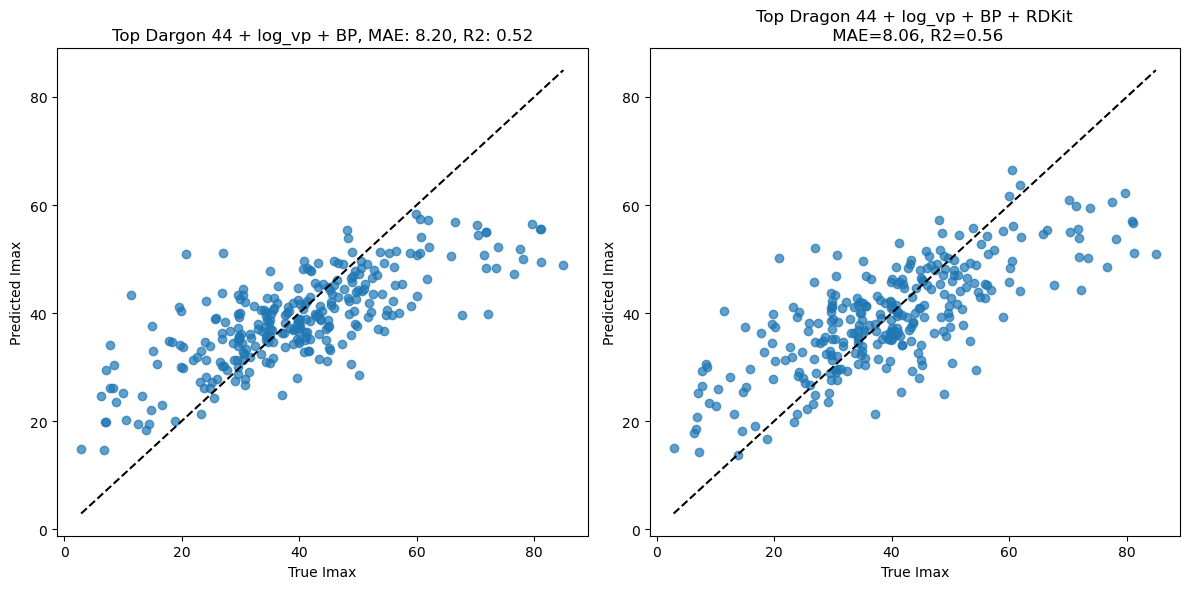

In [167]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6)
)

# Model 1
ax[0].scatter(
    vY_Imax,
    y_pred_46,
    alpha=0.7
)

ax[0].plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

ax[0].set_title(
    f'Top Dargon 44 + log_vp + BP, MAE: {mae_46:.2f}, R2: {r2_46:.2f}'
)

ax[0].set_xlabel('True Imax')
ax[0].set_ylabel('Predicted Imax')

# Model 2
ax[1].scatter(
    vY_Imax,
    y_pred_rdkit_best,
    alpha=0.7
)

ax[1].plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

ax[1].set_title(
    f'Top Dragon 44 + log_vp + BP + RDKit\n MAE={mae_rdkit:.2f}, R2={r2_rdkit:.2f}'
)

ax[1].set_xlabel('True Imax')
ax[1].set_ylabel('Predicted Imax')

plt.tight_layout()
plt.show()